In [1]:
import numpy as np
from skimage import io, feature, color, draw, util, measure
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
# import sys
# sys.path.append(r'C:\Users\jglic\Documents\School\WashU\Mukherji Lab\organelle-measure\organelle_measure')
# from cell_cycle import cc_sort

## To add:
1. Overlay mother & bud A(t) curves onto their corresponding myo1 signal timelapses.

In [2]:
def remove_border(img_path: str):
    """
    Args: Path to aff transf img with irrational border pixels
    Outputs: Img with said pixel values set to 0
    """
    img=io.imread(img_path)
    t,y,x=img.shape
    for time in range(t):
        for yind in range(y):
            for xind in range(x):
                if img[time,yind,xind]%1!=0:
                    img[time,yind,xind]=0
    io.imsave(fname=img_path[:-4]+'_no-border.tif', arr=img)

In [15]:
remove_border(r'C:\Users\jglic\Downloads\11052025 myo1\BF-timelapse_cpsam-d10-ms8_afftransf.tif')

In [2]:
def exp_fnc(x: float, a: float, b: float, c: float):
    """
    Args: Four paramters consisting of an independent variable (x) and three fitting params (a,b,c).
    Ouputs: A float value from plugging all of the variables into a generic exponential function form. 
    """
    return a * np.exp(-b * x) + c

In [3]:
def detect_globular_rois(img_or_path, frame_index=0,
                         min_sigma=1, max_sigma=3, num_sigma=10,
                         threshold=0.2, overlap=0.5,
                         roi_radius=5, return_overlay=True):
    """
    Detect globular signals, draw circular ROIs around their centroids, and compute the sum intensity of pixels within.

    Args:
      img_or_path: 2D numpy array or path to a TIF (can be a stack but channel order must be in txy or tyx).
      frame_index: if img_or_path is a stack, index of frame to analyze.
      min_sigma, max_sigma, num_sigma, threshold, overlap: skimage.blob_log params.
      roi_radius: if None, radius = sqrt(2)*sigma for each blob; otherwise fixed radius in pixels.
      return_overlay: if True, also return an RGB image with circular ROI outlines.
    Returns:
      results: dataframe from list of dicts: {'y':..., 'x':..., 'radius':..., 'sum':...}
      overlay (optional): RGB image (uint8) with red ROI outlines overlaid on the analyzed frame.
    """
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #Work only on the designated frame.
    if img.ndim == 3:
        img_f = img[frame_index,:,:] #(t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img_f = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    # img_f = util.img_as_float(img_f)/np.max(img_f)

    #Detect blobs using Laplacian of Gaussian.
    blobs = feature.blob_log(img_f, min_sigma=min_sigma, max_sigma=max_sigma,
                             num_sigma=num_sigma, threshold_rel=threshold, overlap=overlap)
    results = [] 
    overlay = None
    if return_overlay==True:
        rgb = color.gray2rgb(util.img_as_ubyte(img_f/np.max(img_f)))
        overlay = rgb.copy()

    roi_ind=0 #generate ROI index to distinguish unique ROIs
    #plot the ROIs for each detected blob
    for y, x, sigma in blobs: 
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius 
        r_int = int(max(1, round(r)))

        if (y-r)<0 or (y+r)>img_f.shape[1] or (x-r)<0 or (x+r)>img_f.shape[0]: #exclude those rois touching the image boundary
            continue
        else:
            rr, cc = draw.disk((y, x), r_int, shape=img_f.shape)
            sum_intensity = float(img_f[rr, cc].sum()) 
            avg_intensity = sum_intensity/(img_f.shape[0]*img_f.shape[1])
            results.append({'ROI_ID': roi_ind,'frame':frame_index,'y': float(y), 'x': float(x), 'radius': float(r), 'sum': sum_intensity, 'avg': avg_intensity}) 
            if return_overlay: 
                pr, pc = draw.circle_perimeter(int(round(y)), int(round(x)), r_int, shape=overlay.shape[:2]) 
                overlay[pr, pc] = (255, 255, 0) #sets color of ROI circles using RGB values.
            roi_ind+=1 
    if return_overlay==True: 
        io.imshow(overlay)
    return pd.DataFrame.from_dict(results)


In [4]:
def roi_overlap(x1,y1,x2,y2, roi_radius: int, shape: tuple): 
    """
    Args: Two sets of x-y centroid coords, roi radius paramter.
    Outputs: Fractional overlap between disks of equal radius centered about each centroid given.
    """

    if np.absolute(x1-x2)>(2*roi_radius) or np.absolute(y1-y2)>(2*roi_radius): #If overlap impossible, don't bother.
        frac_olap=0
    else: #otherwise, do the overlap calculation
        rr1, cc1 = draw.disk((y1, x1), roi_radius, shape=shape) #generate a disk mask about first centroid; variables contain pixel coords.
        dummy1=np.ones(shape) #dummy array for overlap measure
        dummy1[rr1,cc1]=-1 #set ROI pixel values to -1
        mask1=dummy1<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        rr2, cc2 = draw.disk((y2, x2), roi_radius, shape=shape) #generate a disk mask about second centroid; variables contain pixel coords.
        dummy2=np.ones(shape) #dummy array for overlap measure
        dummy2[rr2,cc2]=-1 #set ROI pixel values to -1
        mask2=dummy2<0 #Apply Boolean statement such that ROI pixels become Trues and all else become Falses.
        frac_olap=measure.intersection_coeff(mask1, mask2) #measure fractional overlap of Boolean ROI masks.
    return frac_olap

def analyze_budnecks(img_or_path: str or numpy.ndarray,  roi_radius: int,  sweep_radius: int, olap_thresh: float=0.5, frame_buffer: int=2):
    """
    Args: Image matrix or path to image file, threshold for sufficient fractional overlap, number of frames for buffer on either end of detected time region
    Outputs: Dataframe consisting of roi id, frame number, x-y centroid coords, roi radius, and sum pixel intensity w/in roi
    for each detected globular signal within each frame of time lapse. 
    """
    
    if isinstance(img_or_path, (str, bytes)):
        img_f = io.imread(img_or_path) 
    else:
        img_f = np.asarray(img_or_path)
    shape=(img_f.shape[1],img_f.shape[2])
    
    for frame_i in range(img_f.shape[0]): #for each frame in timelapse...
        print('processing frame '+str(frame_i)+'/'+str(np.max(img_f.shape[0])-1))
        if frame_i==0: #run initial globular detection 
            running_list=detect_globular_rois(img_f, frame_index=frame_i, roi_radius=roi_radius, return_overlay=False) 
        else: #for each frame past the first...
            cand_globs=detect_globular_rois(img_f, frame_index=frame_i, roi_radius=roi_radius, return_overlay=False) 
            no_overlap_idxs=[]
            established_ids=list(np.unique(running_list['ROI_ID'].values))
            
            for cand_idx in cand_globs.index: #for each candidate new roi...
                candx, candy = cand_globs.iloc[cand_idx]['x'], cand_globs.iloc[cand_idx]['y'] #extract centroid coords of candidate ROI
                overlap_ids, overlaps=[],[] 

                for estb_id in established_ids: #for each preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id #generate mask of its dataframe row
                    if frame_i-running_list[estb_mask]['frame'].values[-1]<=1: #if is with recent-enough roi...
                        estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                        if (candx-estbx)**2 + (candy-estby)**2 < (2*roi_radius)**2: #if the centroids are in the same neighborhood
                            overlap=roi_overlap(candx,candy,estbx,estby,roi_radius,shape) #calculate fractional overlap between candidate roi and each previous one.
                            if overlap>=olap_thresh: 
                                overlap_ids.append(estb_id)
                                overlaps.append(overlap)
                        # else: #otherwise, move along through the rest of the established rois.
                        #     continue #move along, move along like i know ya do. move along, move along just to make it through
                if len(overlap_ids)>0: #if at least one overlap option
                    new_id=overlap_ids[overlaps.index(np.max(overlaps))] 
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #reassign candidate roi_id to that of established roi with max overlap
                    established_ids.remove(new_id)
                else:
                    no_overlap_idxs.append(cand_idx) #record candidates and estbs that don't meet the overlap threshold.

            id_ind=1 #reset dummy id index value to use when assigning new, unique roi_ids to new signals.
            for cand_idx in no_overlap_idxs:
                candx, candy = cand_globs.iloc[cand_idx]['x'], cand_globs.iloc[cand_idx]['y'] #extract centroid coords of candidate ROI
                neighbor_ids, dists=[],[]
                for estb_id in established_ids: #for each unmatched/available preexisting ROI...
                    estb_mask=running_list['ROI_ID'].values==estb_id
                    if frame_i-running_list[estb_mask]['frame'].values[-1]<=1: #if is recent-enough roi...
                        estbx, estby = running_list[estb_mask]['x'].values[-1], running_list[estb_mask]['y'].values[-1] #extract most recent centroid coords of established ROI
                        if dist:=((candx-estbx)**2 + (candy-estby)**2) < (sweep_radius)**2: #if the centroids are in the same neighborhood
                            neighbor_ids.append(estb_id)
                            dists.append(dist)
                if len(neighbor_ids)>0: #if at least one neighbor option
                    new_id=neighbor_ids[dists.index(np.min(dists))] 
                    # print('assign '+str(new_id))
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #reassign candidate roi_id to that of established roi with max overlap
                    established_ids.remove(new_id)
                
                else: #if insufficient dist to preexisting signals...
                    new_id=(np.max(running_list['ROI_ID'].values)+id_ind)
                    # print('new '+str(new_id))
                    cand_globs.loc[cand_globs.index==cand_idx, 'ROI_ID']=new_id #assign new id to accepted source
                    id_ind+=1 #update dummy id index to reflect new signal recognized.
                
            running_list=pd.concat([running_list,cand_globs], ignore_index=True) #append this frame's information to running dataframe.
    
    #When possible, add frame buffer to either end of detected region.
    buffer_dicts=[]          
    r_int = int(max(1, round(roi_radius))) #radius must be an integer value of pixels greater than or equal to one.
    unique_rois=np.unique(running_list['ROI_ID'].values) 
    for roi_id in unique_rois: #for each unique roi detected...
        print('processing buffer frames for '+str(roi_id)+'/'+str(np.max(unique_rois))) #optional frame by frame progress update
        roi_slice=running_list[running_list['ROI_ID']==roi_id]
        first_frame,last_frame=roi_slice['frame'].values[0],roi_slice['frame'].values[-1]
        
        if first_frame>0:
            x,y=roi_slice.loc[roi_slice.frame==first_frame,'x'].values[0], roi_slice.loc[roi_slice.frame==first_frame,'y'].values[0]
            
            for frame_offset in np.arange(1,frame_buffer+1): #for each buffer frame asked for...
                
                if (first_frame-frame_offset)>=0: #if the frame exists to measure, then measure using roi from first_frame.
                    rr, cc = draw.disk((y, x), r_int, shape=(img_f.shape[1],img_f.shape[2])) #generate a disk mask about each given centroid.
                    sum_intensity = float(img_f[first_frame-frame_offset,rr, cc].sum()) #sum all pixel intensities within said disk.
                    avg_intensity = sum_intensity/(len(rr)*len(cc))
                    buffer_dicts.append({'ROI_ID': roi_id,'frame':(first_frame-frame_offset),'y': float(y), 'x': float(x), 'radius': float(roi_radius), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
      
        if last_frame<(img_f.shape[0]-1): #if last frame before the end of time lapse...
            x,y=roi_slice.loc[roi_slice.frame==last_frame,'x'].values[-1], roi_slice.loc[roi_slice.frame==last_frame,'y'].values[-1]
            
            for frame_offset in np.arange(1,frame_buffer+1): #for each buffer frame asked for...
                
                if (last_frame+frame_offset)<=(img_f.shape[0]-1): #if the frame exists to measure, then measure using roi from last_frame.
                    rr, cc = draw.disk((y, x), r_int, shape=(img_f.shape[1],img_f.shape[2])) #generate a disk mask about each given centroid.
                    sum_intensity = float(img_f[last_frame+frame_offset,rr, cc].sum()) #sum all pixel intensities within said disk.
                    avg_intensity = sum_intensity/(len(rr)*len(cc))
                    buffer_dicts.append({'ROI_ID': roi_id,'frame':(last_frame+frame_offset),'y': float(y), 'x': float(x), 'radius': float(roi_radius), 'sum': sum_intensity, 'avg': avg_intensity}) #append the summed intensity and other relevant metrics to the results dictionary.
    buffer_df=pd.DataFrame.from_dict(buffer_dicts)
    output_df=pd.concat([running_list,buffer_df], ignore_index=True) #append buffer frame info to initial detection analysis.  
    output_df=output_df.sort_values(by=['frame'])
    return output_df


In [5]:
def myo1_postproc(myo1df: pd.DataFrame):
    """
    Args: Dataframe of myo1 roi info
    Outputs: Same dataframe with new column for myo1 intensity normalized by roi max
    """
    for roi_id in np.unique(myo1df['ROI_ID'].values):
        roi_rows=myo1df.loc[myo1df.ROI_ID==roi_id]
        norm_int=[(roi_rows['sum'].values[i]/np.max(roi_rows['sum'].values)) for i in range(len(roi_rows))]
        myo1df.loc[myo1df.ROI_ID==roi_id, 'norm_int']=norm_int 
    return myo1df


In [ ]:
# aapath=r'C:\Users\jglic\Downloads\06102026 myo1 high time res\autoassigntable_r=4_newassign.csv'
# aaout=myo1_postproc(pd.read_csv(aapath))
# aaout.to_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high time res\autoassigntable_r=4_newassign_norm.csv', index=False)

In [6]:
def plot_signal(df, roi_ind, metric, plot_graph=False):
    """
    Args: Dataframe (or its corresponding file path) containing at least roi ids, frame numbers, and desired metric(s) to plot. Optional Boolean arg to generate plot.
    Outputs: Dataframe containing same info as input. Optional plot.
    """
    if plot_graph==True:
        plt.figure()
        for roi in np.unique(df['ROI_ID'].values)[roi_ind:roi_ind+1]: #for each detected roi in entire time lapse...
            mask=df['ROI_ID'].values==roi #create a mask to extract roi's rows
            roi_subset=df[mask] #apply mask
            plt.plot(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values)) #plots desired metric as function of frame (proxy for time)
            plt.scatter(roi_subset['frame'].values,roi_subset[metric].values/np.max(roi_subset[metric].values), label='Roi_'+str(roi))
        plt.xlabel('Time (min)')
        plt.xlim(0,np.max(df['frame'].values)) #fix x and y bounds to whole range of values
        plt.ylim(0,1)
        # plt.ylabel('Normalized Sum Interior Pixel Intensity (AU)')
    return df

def roi_paths(df: pd.DataFrame, roi_id, roi_radius: int, img_shape: int=1024):
    """
    Args: Dataframe containing the (x,y) coords of roi(s) to visualize for each frame detected, ID of roi to display, radius of roi disk. 
    Outputs: Plot/image depicting the path of roi centroids and/or disks in coordinate space. 
    """
    id_mask=df['ROI_ID'].values==roi_id #generate mask for rows with roi_id matching that of argument
    rx, ry = df[id_mask]['x'].values, df[id_mask]['y'].values #extract centroid coords of candidate ROI
    ax.scatter(rx, ry, label='ROI Centroids')
    ax.set_xlim(0,img_shape)
    ax.set_ylim(0,img_shape)
    ax.annotate(str(roi_id), (rx[-1], ry[-1]),fontsize='x-small')
    ax.yaxis.set_inverted(True)


In [27]:
def run_analyzebudnecks(img_path: str, roi_radius: int, sweep_radius: int):
    """
    Args: Path to input myo1 time seris tif file.
    Outputs: Save analysis csv and return it as a dataframe.
    """
    myo1df=analyze_budnecks(img_path, roi_radius=roi_radius, sweep_radius=sweep_radius)
    output_name=Path(img_path).stem + '_r='+str(roi_radius)+'.csv'
    output_path=Path(img_path).parent/f"{output_name}"
    myo1df.to_csv(output_path, index=False)
    print(len(np.unique(myo1df['ROI_ID'].values)))
    return myo1df

In [28]:
julrun=run_analyzebudnecks(r'C:\Users\jglic\Downloads\07172026 myo1 high res\confyellow-jg_07172026_myo1-mlemon_glucose-2.0_fov1_despeckle.tif', roi_radius=4, sweep_radius=10)

processing frame 0/40
processing frame 1/40
processing frame 2/40
processing frame 3/40
processing frame 4/40
processing frame 5/40
processing frame 6/40
processing frame 7/40
processing frame 8/40
processing frame 9/40
processing frame 10/40
processing frame 11/40
processing frame 12/40
processing frame 13/40
processing frame 14/40
processing frame 15/40
processing frame 16/40
processing frame 17/40
processing frame 18/40
processing frame 19/40
processing frame 20/40
processing frame 21/40
processing frame 22/40
processing frame 23/40
processing frame 24/40
processing frame 25/40
processing frame 26/40
processing frame 27/40
processing frame 28/40
processing frame 29/40
processing frame 30/40
processing frame 31/40
processing frame 32/40
processing frame 33/40
processing frame 34/40
processing frame 35/40
processing frame 36/40
processing frame 37/40
processing frame 38/40
processing frame 39/40
processing frame 40/40
processing buffer frames for 0/459
processing buffer frames for 1/4

In [29]:
# julrun=analyze_budnecks(r'C:\Users\jglic\Downloads\07172026 myo1 high res\confyellow-jg_07172026_myo1-mlemon_glucose-2.0_fov1.tif', roi_radius=4, sweep_radius=10)
# junerun=analyze_budnecks(r'C:\Users\jglic\Downloads\6-10-26 myo1 high time res\smooth_SUM-confyellow-jg_06102026_ey2795-myo1_glucose-2.0_fov1.tif', roi_radius=4, sweep_radius=10)
# novrun=analyze_budnecks(r'C:\Users\jglic\Downloads\11052025 myo1\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2.tif', roi_radius=3, sweep_radius=6)
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\Run_2\SUM_20251212_yfp-216nm_Run-2.tif')
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\SUM_20260129_131049_173__ChannelEYFPpH 7_Seq0000.tif')
# janrun,tb=analyze_budnecks(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\SUM_20260129_132732_869__ChannelEYFPpH 7_Seq0000.tif')

In [30]:
# julrun.to_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\confyellow-jg_07172026_myo1-mlemon_glucose-2.0_fov1_r=4.csv')
# junerun.to_csv(r'C:\Users\jglic\Downloads\6-10-26 myo1 high time res\smooth_SUM-confyellow-jg_06102026_ey2795-myo1_glucose-2.0_fov1_r=4.csv', index=False)
# novrun.to_csv(r'C:\Users\jglic\Downloads\11052025 myo1\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\1-22-26 myo1-mLemon\signal-analysis_01222026.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_12122025.csv', index=False)
# janrun.to_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-1.csv',index=False)

In [31]:
# juldf=julrun
# juldf=pd.read_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\confyellow-jg_07172026_myo1-mlemon_glucose-2.0_fov1_r=4.csv')
# junedf=pd.read_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\smooth_SUM-confyellow-jg_06102026_ey2795-myo1_glucose-2.0_fov1_r=4.csv')
# smoodf=pd.read_csv(r'C:\Users\jglic\Downloads\6-10-26 myo1 high time res\smooth_SUM-confyellow-jg_06102026_ey2795-myo1_glucose-2.0_fov1_r=4.csv')
# novdf=pd.read_csv(r'C:\Users\jglic\Downloads\11052025 myo1\eyrbow-yellowconfocal_zstack-avg-proj_myo1_fov2.csv')
# df_12122025=pd.read_csv(r'C:\Users\jglic\Downloads\Run_2\signal-analysis_12122025.csv')
# df_01222026=pd.read_csv(r'C:\Users\jglic\Downloads\1-22-26 myo1-mLemon\signal-analysis_01222026.csv')
# df_01292026_r1=pd.read_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-1.csv')
# df_01292026_r2=pd.read_csv(r'C:\Users\jglic\Downloads\1-29-26 myo1-mLemon photobleaching\signal-analysis_01292026_Run-2.csv')

In [33]:
# junedf
# print(len(np.unique(junedf['ROI_ID'].values)))
print(len(np.unique(julrun['ROI_ID'].values)))

460


In [25]:
def overlay_roi(img_or_path: str or np.ndarray, roi_df: pd.DataFrame, roi_ids: list, roi_radius: int=3, frame_index: int=0):
    """
    Args: Image or path to it, df containing extracted roi info, list of rois to overlay, kwargs.
    Outputs: Overlay of rois on image.
    """
    if isinstance(img_or_path, (str, bytes)):
        img = io.imread(img_or_path) #file path
    else:
        img = np.asarray(img_or_path) #image matrix

    #If image is a stack (time lapse), work only on the designated frame.
    if img.ndim == 3:
        img2d = img[frame_index,:,:] #(t,y,x) or (t,x,y) channel order.
    elif img.ndim == 2:
        img2d = img
    else:
        raise ValueError("Image must be 2D or 3D stack")

    #Normalize image pixel values
    # img_f = util.img_as_float(img2d)/np.max(img2d)
    img_f=img2d

    overlay = None
    rgb = color.gray2rgb(util.img_as_ubyte(img_f/np.max(img_f)))
    overlay = rgb.copy()

    for id in roi_ids:
        id_mask=roi_df['ROI_ID'].values==id #generate mask for rows with roi_id matching that of argument
        rx, ry = roi_df[id_mask]['x'].values[frame_index], roi_df[id_mask]['y'].values[frame_index] #extract centroid coords of candidate ROI
        r = (np.sqrt(2) * sigma) if roi_radius is None else roi_radius #compute radius if none is set, otherwise use given value.
        r_int = int(max(1, round(r))) #radius must be an integer value of pixels greater than or equal to one. 
        pr, pc = draw.circle_perimeter(int(round(ry)), int(round(rx)), r_int, shape=None) #draw the circular ROIs around the glob centroids.
        overlay[pr-1, pc-1] = (255, 255, 0) #sets color of ROI circles using RGB values.
    io.imshow(overlay)
    return

c:\Python310\lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:149: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


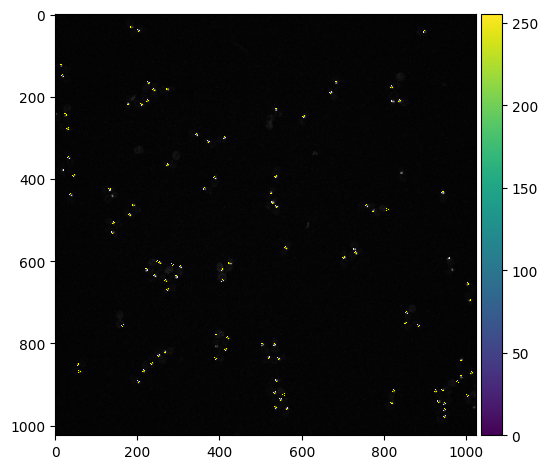

In [39]:
imgpath=r'C:\Users\jglic\Downloads\6-10-26 myo1 high time res\smooth_SUM-confyellow-jg_06102026_ey2795-myo1_glucose-2.0_fov1.tif'
overlay_roi(imgpath,smoodf,smoodf.loc[smoodf.frame==0,'ROI_ID'])

In [66]:
# plt.figure()
# # for id_i in np.unique(novdf['ROI_ID'].values):
# ids=np.arange(0,100,1)
#     # savestem=r'C:\Users\jglic\Downloads\11-5-25 myo1-mLemon\Run_2\roi_frames'
#     # plt.figure()
# overlay_roi(ti,novdf,[ids])
#     # plt.savefig(Path(savestem)/f'roi-{id_i}.png')
#     # plt.close()

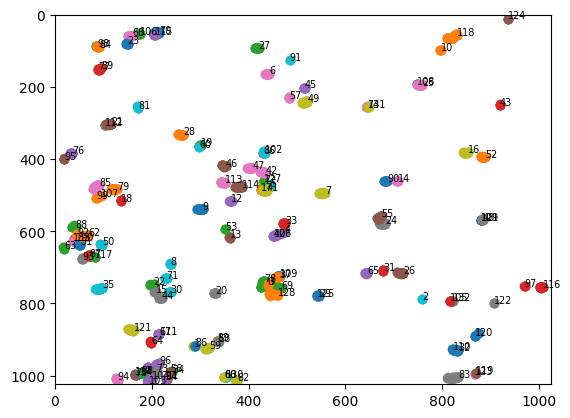

In [24]:
# dind=0
# df=analyze_signal(df_01222026, roi_ind=dind,metric='sum', plot_graph=True)
fig, ax = plt.subplots()
# for id in np.unique(novdf['ROI_ID'].values):

ids=juldf.loc[juldf.frame==0, 'ROI_ID'].values
for id in ids:
    # roi_paths(junedf, roi_id=id, roi_radius=2)
    roi_paths(juldf, roi_id=id, roi_radius=2)
# dind+=2

In [12]:
juldf.loc[juldf.ROI_ID==6]

,ROI_ID,frame,y,x,radius,sum,avg
6,6,0,163.0,433.0,4.0,10123.0,0.009654
134,6,1,164.0,433.0,4.0,9725.0,0.009274
239,6,2,163.0,435.0,4.0,9868.0,0.009411
371,6,3,164.0,435.0,4.0,9390.0,0.008955
485,6,4,163.0,436.0,4.0,7929.0,0.007562
590,6,5,164.0,436.0,4.0,10193.0,0.009721
704,6,6,163.0,438.0,4.0,9929.0,0.009469
827,6,7,163.0,438.0,4.0,11030.0,0.010519
942,6,8,164.0,438.0,4.0,11214.0,0.010695
1062,6,9,163.0,439.0,4.0,11993.0,0.011437


In [26]:
def ticks(img_df: pd.DataFrame, thresh: float=0.5):
    """
    Args: Dataframe containing extracted roi info to be analyzed.
    Outputs: Dataframe containing up and/or down tick frames for each unique roi. 
    """
    dfs=[]
    for roi_id in np.unique(img_df['ROI_ID'].values):
        vals=img_df.loc[img_df.ROI_ID==roi_id, 'sum'].values
        vals=vals/np.max(vals)
        yi=img_df.loc[img_df.ROI_ID==roi_id, 'y'].values[0]
        xi=img_df.loc[img_df.ROI_ID==roi_id, 'x'].values[0]
        frames=img_df.loc[img_df.ROI_ID==roi_id, 'frame'].values
        beg=frames[:4]
        end=frames[-4:]
        start_indices=np.where(beg<thresh)
        end_indices=np.where(end>thresh)
        # diffs=np.diff(vals)
        # indices=np.where(abs(diffs)>thresh)[0]
        if len(start_indices)>0:
            start_frame=beg[start_indices[0]]+1
        else:
            start_frame=None
        if len(end_indices)>0:
            div_frame=end[end_indices[-1]]+1
        else:
            div_frame=None
        
        # start_frame=None
        # div_frame=None
            # if diffs[ind]>0:
            #     start_frame=frames[ind]+1
            # else:
            #     div_frame=frames[ind] 

        metrics={
            "ROI_ID"      : [roi_id],
            "y"           : [yi],
            "x"           : [xi],
            "Start_Frame" : [start_frame],
            "Div_Frame"   : [div_frame]
        }

        roi_df=pd.DataFrame(metrics)
        dfs.append(roi_df)
    output_df=pd.concat(dfs, ignore_index=True)
    return output_df

In [17]:
# tt=ticks(novdf)
# # tf['Start Frame'][400:500]
# sframes=[s for s in tt['Start_Frame'].values if s is not None]
# dframes=[d for d in tt['Div_Frame'].values if d is not None]

NameError: name 'sframes' is not defined

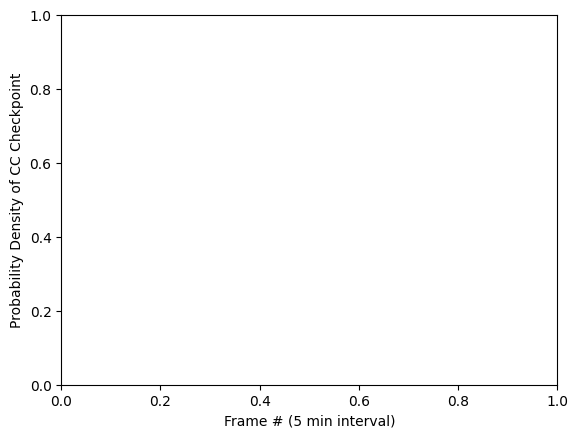

In [18]:
plt.figure()
plt.xlabel('Frame # (5 min interval)')
plt.ylabel('Probability Density of CC Checkpoint')
n0,b0,p0=plt.hist(sframes,bins='doane', alpha=0.75, edgecolor='black', density=True, color='y', label='Starts')
n1,b1,p1=plt.hist(dframes, bins='doane', alpha=0.75, edgecolor='black', density=True, color='b', label='Divisions')
plt.legend()

In [35]:
def photobleach_correction(vals: np.ndarray,x: np.ndarray,a: float,b: float,c: float):
    """
    Args: Arrays of uncorrected pixel intensity value and frame indices; Three fitting paramters for exponential fit.
    Outputs: Array of corrected pixel intensity values.
    """
    output_ls=[vals[i]/exp_fnc(x[i],a,b,c) for i in range(len(vals))]
    return output_ls

def roi_subplots(df: pd.DataFrame, num_rows: int, num_columns: int=2, metric: str='sum', normalize: bool=True, thresh: float=0.5, fit: bool=False, corr: bool=True, plot_fit: bool=False):
    """
    Args: Dataframe containing ROI_ID and pixel metric info, row & column dimensions, and optional argument to designate alternative metric.
    Outputs: Fitting parameters for exponential function. Figure consisting of subplots.
    """
    a_vals,b_vals,c_vals=[],[],[]
    plt.figure(figsize=(10,500))

    #Median parameters of exponential decay fits for 01292026_r2 data
    a_med,b_med,c_med=(0.7707111579952284,0.0620886804972008,0.1568112942306607)

    for roi_id in np.unique(df['ROI_ID'].values)[300:400]:
        roi_subset=df[df['ROI_ID'].values==roi_id].sort_values(by=['frame']) #apply roi mask and sort according to frame to deal with buffer frames out of order
        I_vals=roi_subset[metric].values
        frames=roi_subset['frame'].values
        if fit==True:
            #Fit an exponential curve and save fit parameters
            popt, pcov = curve_fit(exp_fnc, roi_subset['frame'].values, roi_subset[metric].values/max_px_val)
            a,b,c=popt
            a_vals.append(a)
            b_vals.append(b)
            c_vals.append(c)
        else:
            a,b,c=0,0,0
        if corr==True:
            I_vals=photobleach_correction(I_vals,frames,a_med,b_med,c_med)
        if normalize==True:
            max_px_val=np.max(I_vals)
        else:
            max_px_val=1
        I_vals=I_vals/max_px_val

        plt.subplot(num_rows,num_columns,roi_id+1) #locate subplot to use
        if plot_fit==True:
            plt.plot(frames, exp_fnc(roi_subset['frame'].values, *popt), 'k--',label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt)) #plot exp fit
        plt.scatter(frames,I_vals,s=4,c='y',edgecolors='k', label='ROI_'+str(roi_id))
        plt.plot(frames,I_vals, label='Data')#plots desired metric as function of frame (proxy for time)
        plt.hlines(y=thresh,xmin=frames[0],xmax=frames[-1])
        
        # plt.ylabel('Pixel Intesity (AU)')
        # plt.xlabel('Frame (5 min intervals)')
        plt.ylim(0,1.25)
        plt.xlim(-1,np.max(df['frame'].values)+5)
        plt.legend(loc='best', fontsize='small')

    plt.show()
    if fit==True:
        return a_vals,b_vals,c_vals
    else:
        return



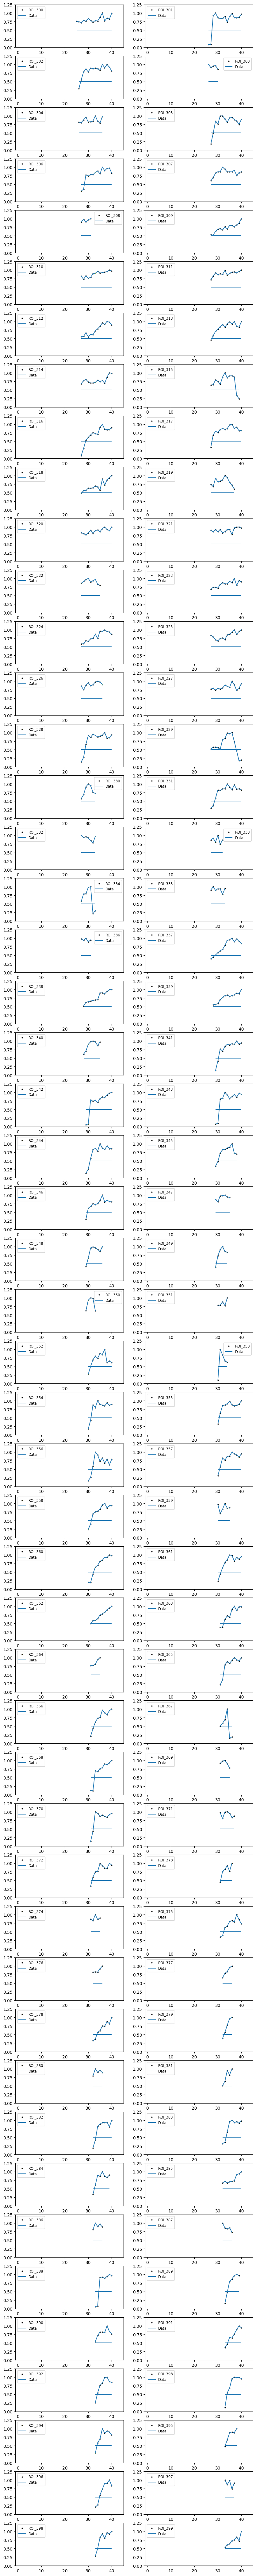

In [36]:
roi_subplots(julrun, num_rows=int(len(np.unique(julrun['ROI_ID'].values))/2),fit=False,corr=False, thresh=0.5)
# roi_subplots(df_01222026, num_rows=int(len(np.unique(df_01222026['ROI_ID'].values))/2),fit=False,corr=True)

In [95]:
novdf.loc[novdf.ROI_ID==45]

,ROI_ID,frame,y,x,radius,sum,avg
204,45,0,784.0,1785.0,8.0,6800.312500,0.001621
562,45,1,782.0,1783.0,8.0,6645.199219,0.001584
843,45,2,782.0,1782.0,8.0,6749.265625,0.001609
1402,45,3,781.0,1783.0,8.0,7141.938477,0.001703
1771,45,4,781.0,1781.0,8.0,7081.733398,0.001688
2084,45,5,780.0,1782.0,8.0,4337.889648,0.001034
2404,45,6,780.0,1782.0,8.0,1601.598633,0.042997
2794,45,7,780.0,1782.0,8.0,1577.347900,0.042346
3134,45,8,780.0,1782.0,8.0,1684.706055,0.045228


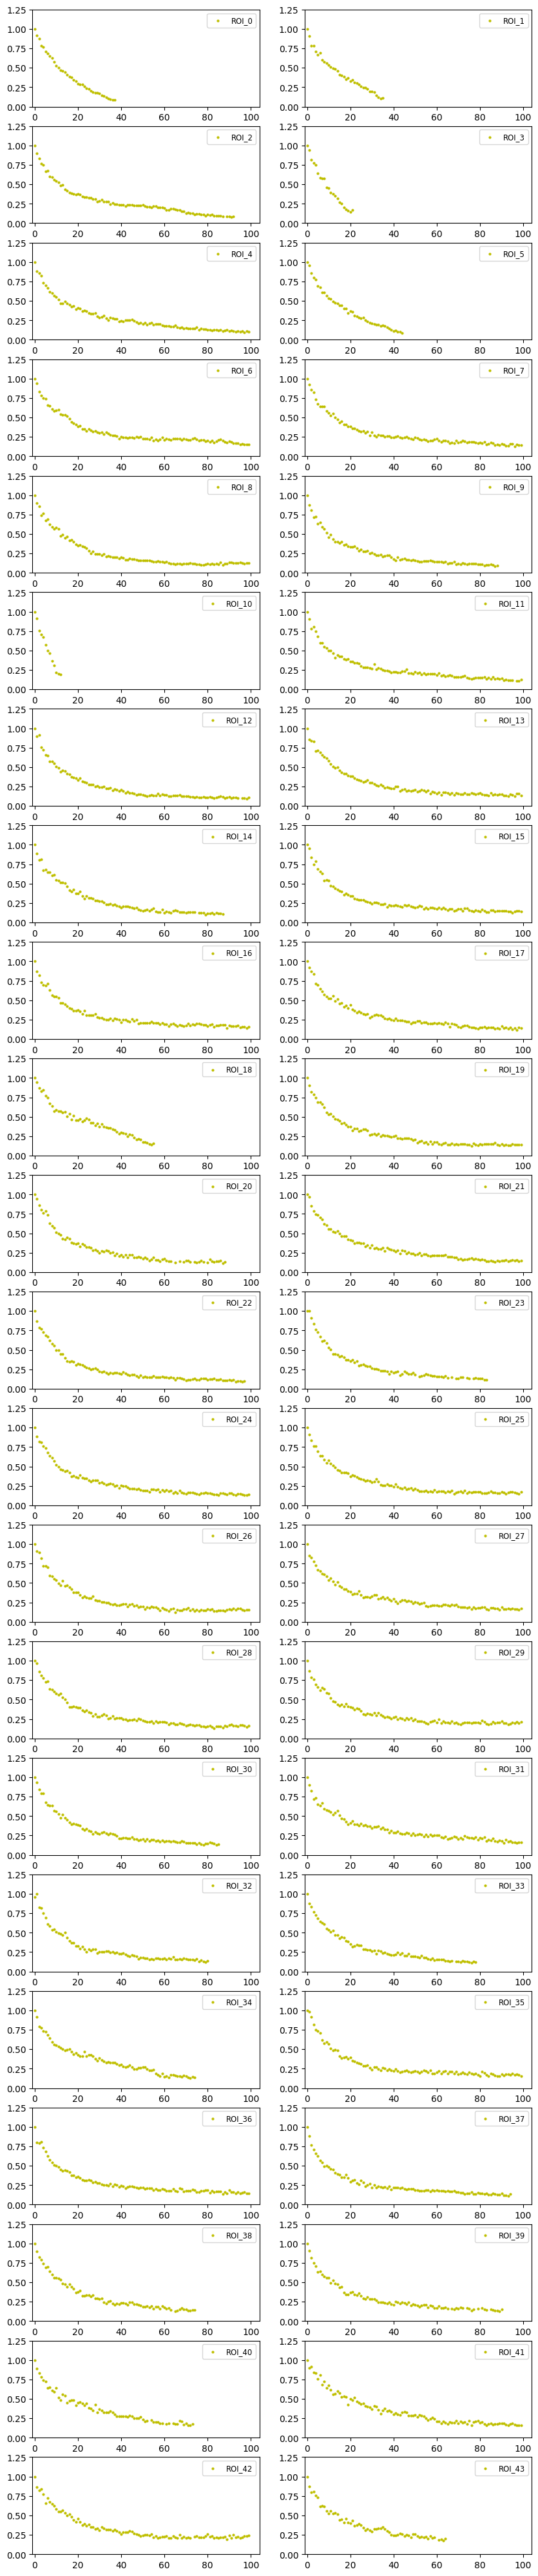

In [15]:
# wa,wb,wc=roi_subplots(df_01292026_r1, num_rows=int(len(np.unique(df_01292026_r1['ROI_ID'].values))/2),fit=True,corr=False)
xa,xb,xc=roi_subplots(df_01292026_r2, num_rows=int(len(np.unique(df_01292026_r2['ROI_ID'].values))/2), fit=True,corr=False)
# roi_subplots(janrun, num_rows=int(len(np.unique(janrun['ROI_ID'].values))/2))

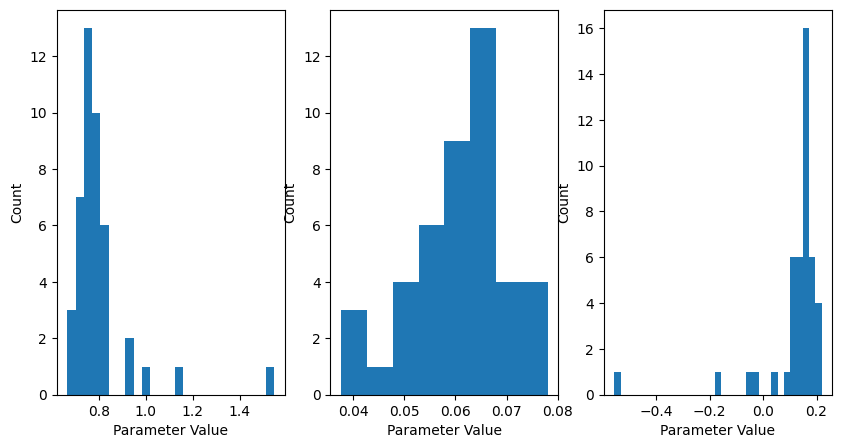

In [16]:
num_rows=1; num_columns=3
# r1_param_vals=[wa,wb,wc]
r2_param_vals=[xa,xb,xc]
plt.figure(figsize=(10,5))
for param_ind in np.arange(0,3):
    plt.subplot(num_rows,num_columns,param_ind+1) #locate subplot to use
    # plt.scatter()
    plt.hist(r2_param_vals[param_ind],bins='fd')
    plt.ylabel('Count')
    plt.xlabel('Parameter Value')
    # plt.legend(loc='best', fontsize='small')
    # plt.title('ROI '+str(roi_id))
 

In [22]:
fa,fb,fc=np.median(xa),np.median(xb),np.median(xc)

In [24]:
print(fa,fb,fc)

0.7707111579952284 0.0620886804972008 0.1568112942306607


In [108]:
# df_01292026.loc[df_01292026.ROI_ID==0].sort_values(by=['frame'])
# janrun.loc[janrun.ROI_ID==0].sort_values(by=['frame'])